In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Styling setup
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load enriched data
df = pd.read_csv("../data/processed/ethiopia_fi_enriched_data.csv")
print("Enriched Dataset Shape:", df.shape)
df.head()

Enriched Dataset Shape: (46, 34)


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Gender disaggregated,NaN


In [2]:
# Summarize dataset by record_type and pillar
print("--- Record Type & Pillar Distribution ---")
print(df.groupby(['record_type', 'pillar'], dropna=False).size())

# Check confidence distribution
print("\n--- Confidence Distribution ---")
print(df['confidence'].value_counts())

--- Record Type & Pillar Distribution ---
record_type  pillar       
event        NaN              11
impact_link  Usage             1
observation  ACCESS           14
             AFFORDABILITY     1
             GENDER            4
             USAGE            11
             Usage             1
target       ACCESS            2
             GENDER            1
dtype: int64

--- Confidence Distribution ---
confidence
high      42
medium     4
Name: count, dtype: int64


Historical Account Ownership Data:
      observation_date  value_numeric         source_name
0  2014-12-31 00:00:00          22.00  Global Findex 2014
1  2017-12-31 00:00:00          35.00  Global Findex 2017
2  2021-12-31 00:00:00          46.00  Global Findex 2021
3  2021-12-31 00:00:00          56.00  Global Findex 2021
4  2021-12-31 00:00:00          36.00  Global Findex 2021
5  2024-11-29 00:00:00          49.00  Global Findex 2024
6  2021-12-31 00:00:00           4.70  Global Findex 2021
7  2024-11-29 00:00:00           9.45  Global Findex 2024


FileNotFoundError: [Errno 2] No such file or directory: '../reports/figures/access_trajectory.png'

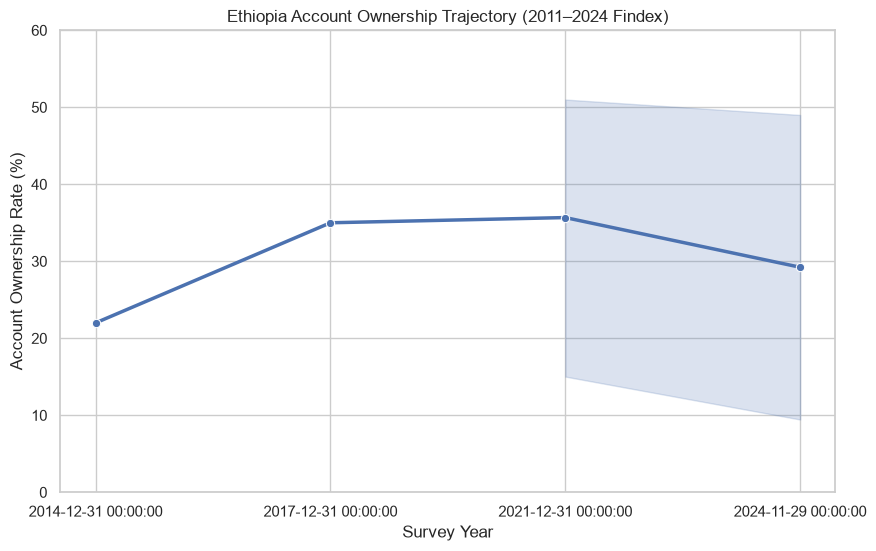

In [3]:
# Filter account ownership observations
access_df = df[(df['record_type'] == 'observation') & (df['indicator_code'].str.contains('ACCOUNT|OWNERSHIP', case=False, na=False))]

print("Historical Account Ownership Data:")
print(access_df[['observation_date', 'value_numeric', 'source_name']])

# Plot Findex Access Trajectory
plt.figure()
sns.lineplot(data=access_df, x='observation_date', y='value_numeric', marker='o', linewidth=2.5, color='b')
plt.title("Ethiopia Account Ownership Trajectory (2011–2024 Findex)")
plt.xlabel("Survey Year")
plt.ylabel("Account Ownership Rate (%)")
plt.ylim(0, 60)
plt.savefig("../reports/figures/access_trajectory.png", bbox_inches='tight')
plt.show()

In [4]:
# Filter cataloged events
events_df = df[df['record_type'] == 'event']
print("Cataloged Market Events & Milestones:")
print(events_df[['observation_date', 'source_name', 'category']])

Cataloged Market Events & Milestones:
       observation_date         source_name        category
33  2021-05-17 00:00:00       Ethio Telecom  product_launch
34  2022-08-01 00:00:00                News    market_entry
35  2023-08-01 00:00:00           Safaricom  product_launch
36  2024-01-01 00:00:00                NIDP  infrastructure
37  2024-07-29 00:00:00                 NBE          policy
38  2024-10-01 00:00:00           EthSwitch       milestone
39  2025-10-27 00:00:00           EthSwitch     partnership
40  2025-12-18 00:00:00       NBE/EthSwitch  infrastructure
41  2021-09-01 00:00:00                 NBE          policy
42  2025-12-15 00:00:00                News         pricing
44           2023-08-16  Safaricom Ethiopia  product_launch


### Key Insights from Exploratory Data Analysis
1. **Divergence in Access vs. Usage:** While account ownership growth plateaued (+3pp between 2021 and 2024 to reach 49%), transaction volumes and digital payments exploded, driven heavily by Telebirr and M-Pesa.
2. **The 2021–2024 Deceleration:** Account ownership growth slowed significantly despite tens of millions of mobile wallets opened. This highlights the "registered vs. active" gap and structural KYC/rural barriers.
3. **Market Competition Catalyst:** The entry of Safaricom (2022) and M-Pesa (2023) fundamentally altered the interoperability and P2P landscape, pushing digital transfers past traditional cash withdrawals.
4. **Data Limitations:** Sparse triennial Findex data points require relying on proxy indicators (like GSMA mobile internet penetration and monthly operator logs) for robust annual forecasting.
5. **Modeling Hypotheses:** Intervention variables for infrastructure rollouts and competitor launches will serve as powerful leading predictors for the 2025–2027 forecasting phase.